# Import necessary libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob

In [2]:
from tensorflow import keras

### Fetch the Training data

In [3]:
cloudy=glob.glob('cloudy/*.jpg')
desert=glob.glob('desert/*.jpg')
green_area=glob.glob('green_area/*.jpg')


In [4]:
print("Images:", len(cloudy))

Images: 1500


### Create a list with the images

In [5]:
image = []
label = []

for i in cloudy:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

    
for i in desert:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

for i in green_area:
    img = plt.imread(i)
    image.append(img)
    label.append(2)

### Shuffle both images and labels

In [6]:
image,label=shuffle(image,label,random_state=100)

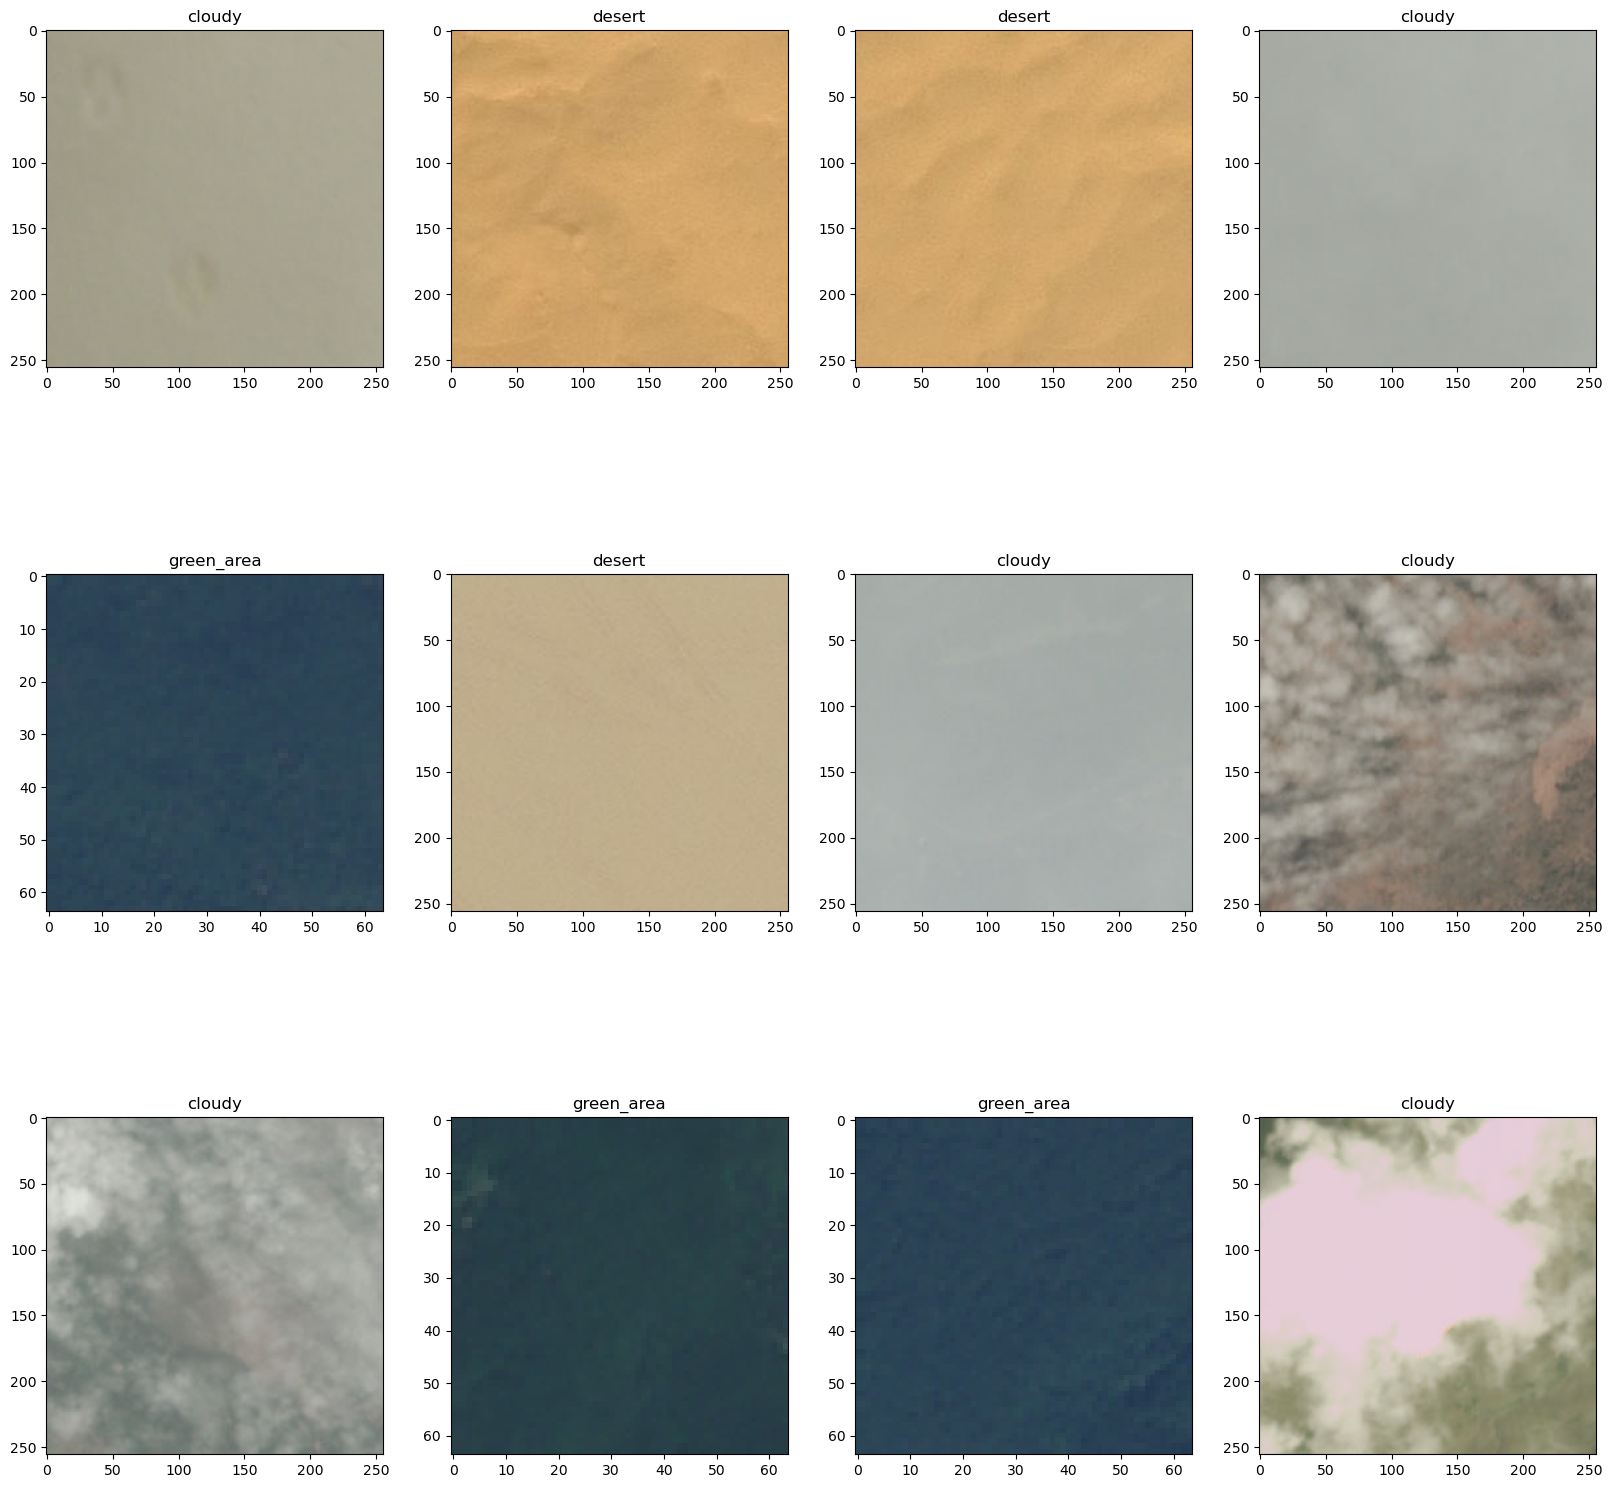

In [7]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 0:
        plt.title('cloudy')
    elif label[i] ==1:
        plt.title('desert')
    else:
        plt.title('green_area')

In [8]:
print("Images:", len(image))
print("Labels:", len(label))
print("Unique labels:", set(label))


Images: 4131
Labels: 4131
Unique labels: {0, 1, 2}


### Resize the images to 64X64

In [9]:
X = []
for i in image:
    X.append(resize(i,(64,64,3)))

X = np.array(X)

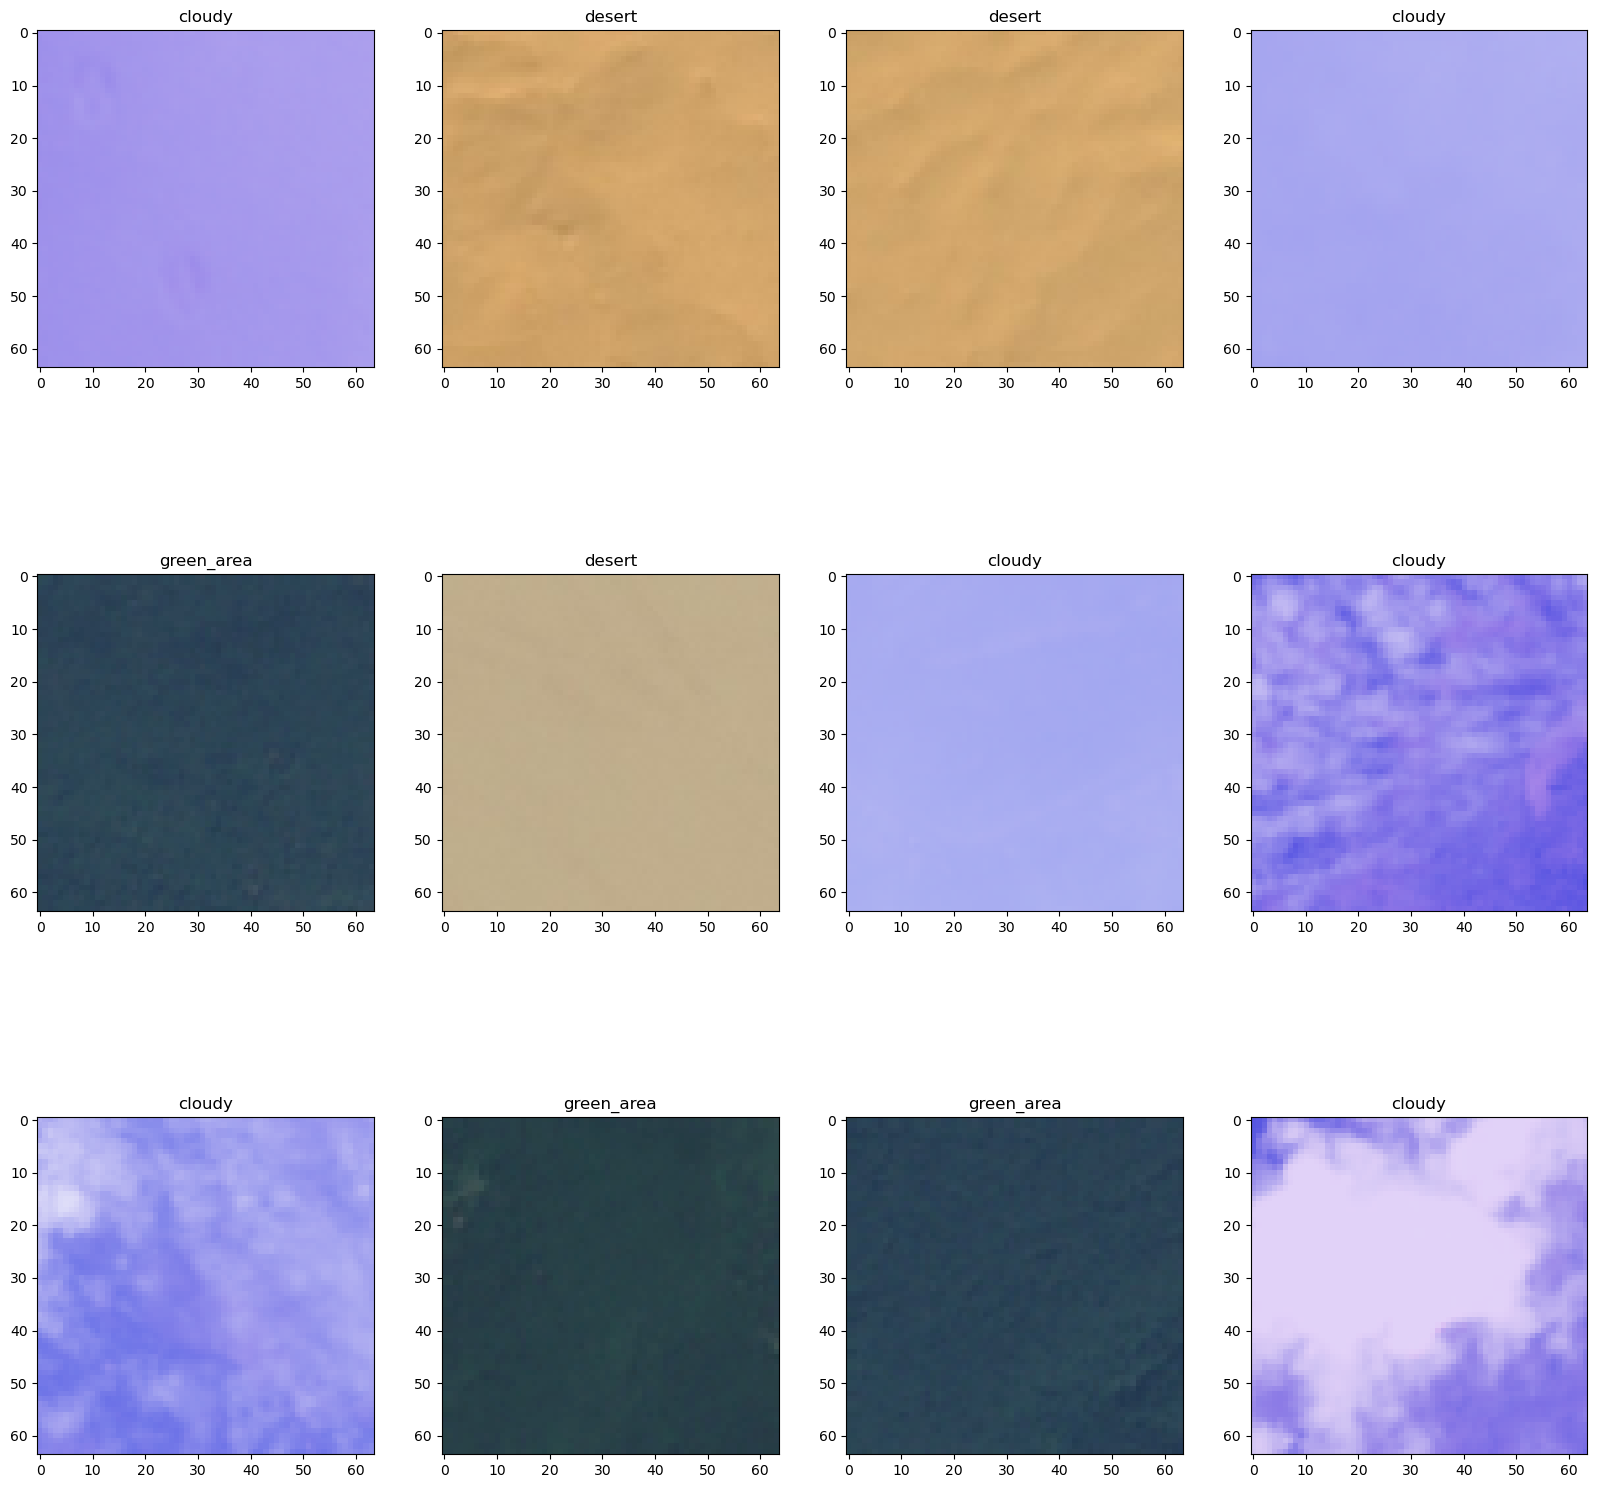

In [10]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i])
    if label[i] == 0:
        plt.title('cloudy')
    elif label[i] ==1:
        plt.title('desert')
    else:
        plt.title('green_area')

In [11]:
y = np.array(label)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [14]:
X_train.shape

(3304, 64, 64, 3)

In [15]:
y_train.shape

(3304,)

### Create Keras Sequential model with 2 convolution layer, Flatten and a Hidden layer

In [16]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(3, activation='softmax')   
])


C:\Users\Std_Evening\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer = 'adam',
             loss = 'sparse_categorical_crossentropy',

             metrics = ['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,755 (1.55 MB)

 Trainable params: 406,755 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
y_train = y_train.astype(int)


In [20]:
#model.add(keras.layers.Dense(3, activation='softmax'))


In [21]:
'''model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)'''


"model.compile(\n    optimizer='adam',\n    loss='sparse_categorical_crossentropy',\n    metrics=['accuracy']\n)"

In [22]:
'''model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.1
)
'''

'model.fit(\n    X_train,\n    y_train,\n    epochs=30,\n    validation_split=0.1\n)\n'

In [23]:
model.fit(X_train,y_train, epochs=30, steps_per_epoch=3, validation_split=0.1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3673 - loss: 1.0746 - val_accuracy: 0.4018 - val_loss: 0.9834
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 688ms/step - accuracy: 0.5002 - loss: 0.8808 - val_accuracy: 0.4743 - val_loss: 0.7840
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 738ms/step - accuracy: 0.5920 - loss: 0.6817 - val_accuracy: 0.5982 - val_loss: 0.5873
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 699ms/step - accuracy: 0.6401 - loss: 0.4995 - val_accuracy: 0.6918 - val_loss: 0.4351
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - accuracy: 0.8819 - loss: 0.3680 - val_accuracy: 0.9879 - val_loss: 0.3092
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 0.9946 - loss: 0.2535 - val_accuracy: 1.0000 - val_loss: 0.1932
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 696ms/step - accuracy: 0.9997 - loss: 0.1528 - val_accuracy: 1.0000 - val_loss: 0.1017
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step - accuracy: 1.0000 - loss: 0.0785 - val_accuracy: 1.0000 - val_loss: 0.

In [24]:
model.evaluate(X_train, y_train)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 2.3643e-04


[0.00023643388703931123, 1.0]

In [25]:
prediction = model.predict(X_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step 


In [26]:
prediction[:10]

array([[9.9999356e-01, 3.0487975e-15, 6.4028536e-06],
       [9.9999630e-01, 3.6651105e-08, 3.6895860e-06],
       [9.9999535e-01, 4.2442474e-13, 4.6559007e-06],
       [5.5553227e-07, 9.9999940e-01, 3.3901038e-08],
       [9.9999583e-01, 1.5127155e-14, 4.1701987e-06],
       [1.6601565e-05, 2.1390215e-06, 9.9998128e-01],
       [2.8148110e-05, 5.6911244e-07, 9.9997127e-01],
       [3.5285491e-05, 9.9995923e-01, 5.4684683e-06],
       [1.7947039e-09, 1.0000000e+00, 3.2751410e-12],
       [5.5961556e-07, 9.9999940e-01, 3.6741440e-08]], dtype=float32)

In [29]:
pred = np.argmax(prediction, axis=1)


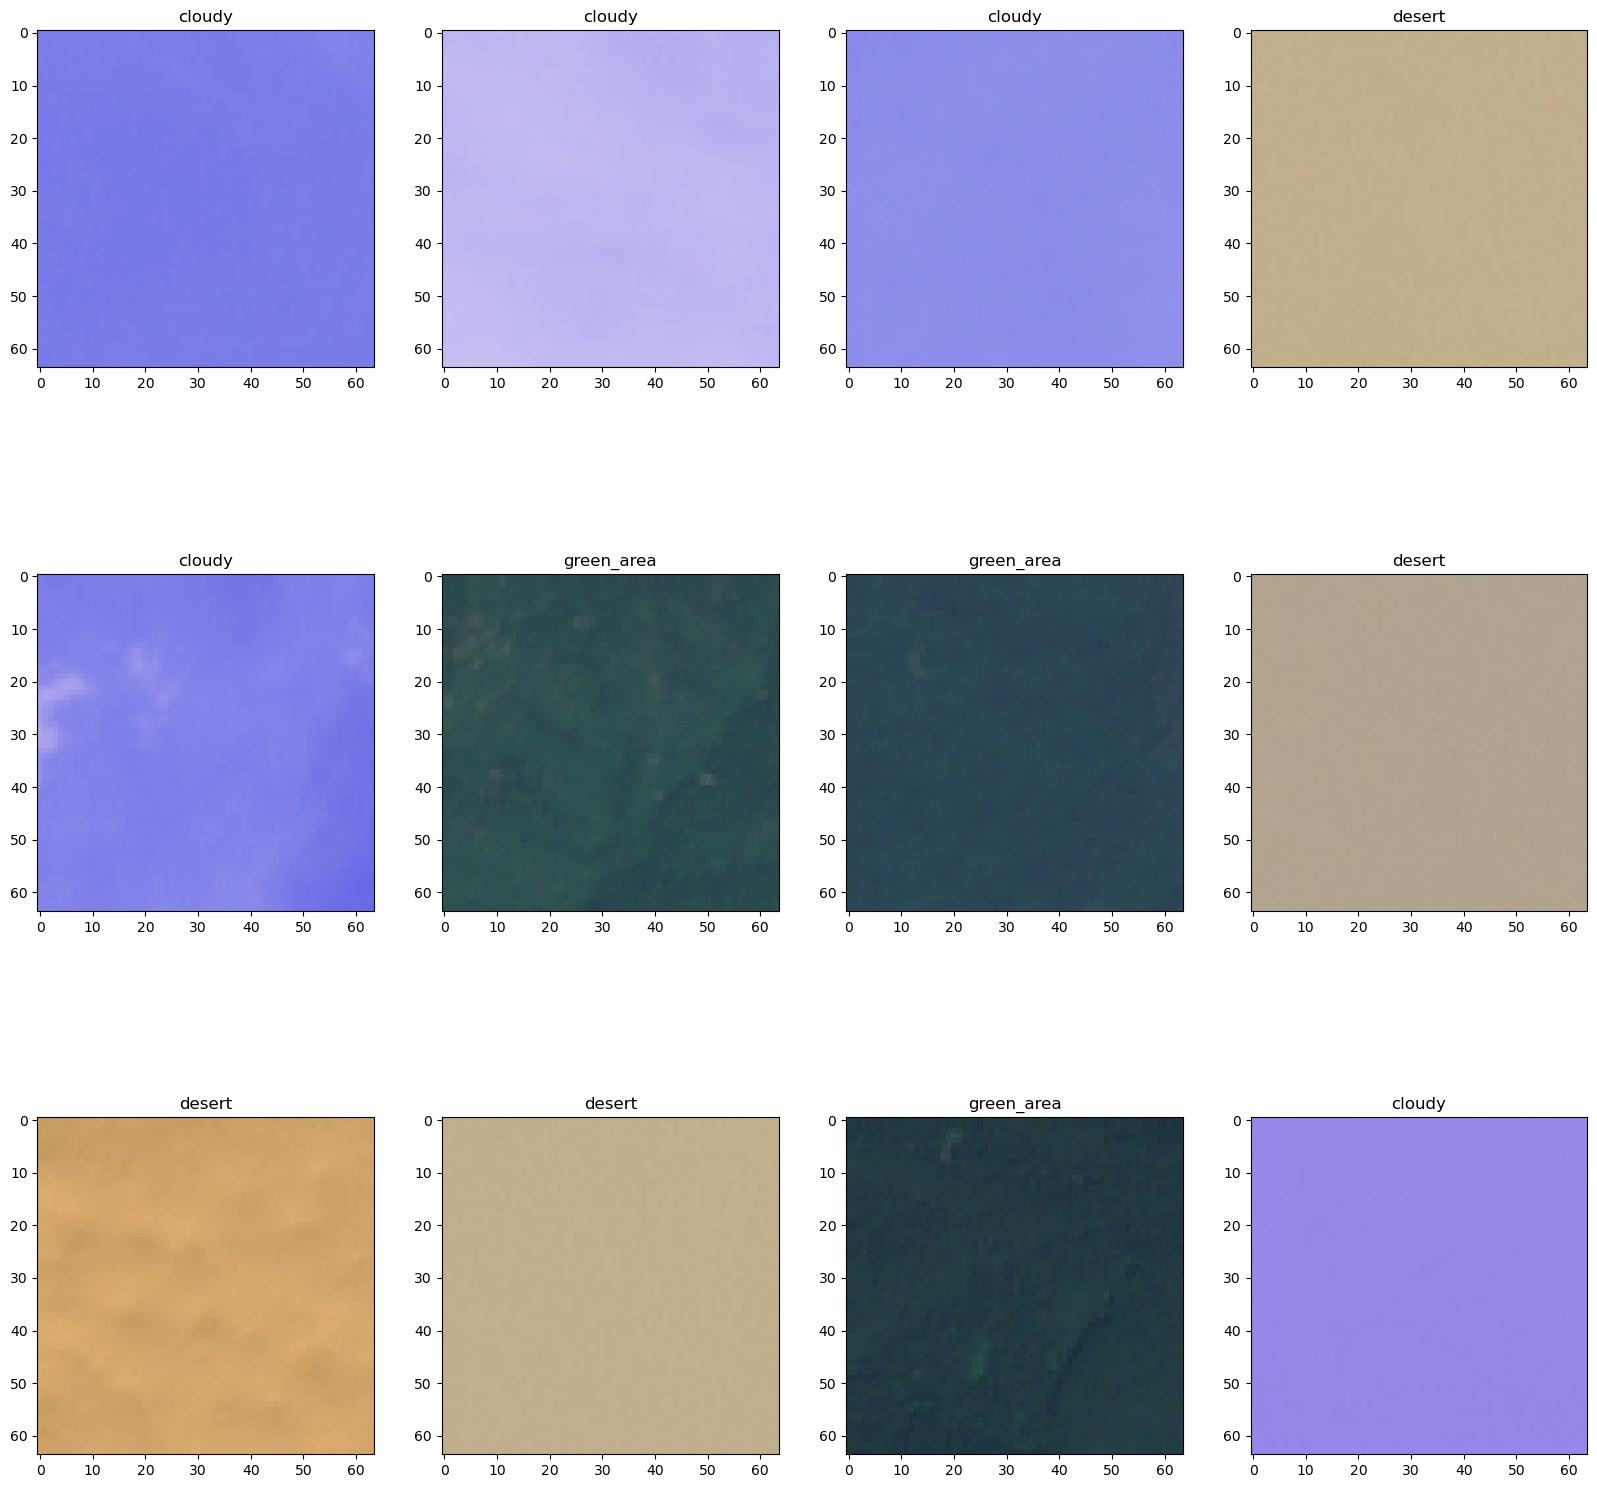

In [30]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 0:
        plt.title('cloudy')
    elif pred[i] == 1:
        plt.title('desert')
    else:
        plt.title('green_area')

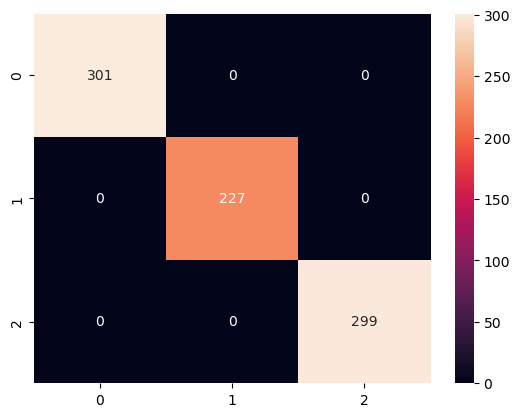

In [31]:
sns.heatmap(confusion_matrix(y_test,pred),fmt='d', annot = True)
plt.show()